In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-testing-master.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [4]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [5]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
#Checking messy categories like extra spaces, inconsistent casing, or typos
print(df['Gender'].value_counts())
print(df['Subscription Type'].value_counts())
print(df['Contract Length'].value_counts())

Gender
Female    34353
Male      30021
Name: count, dtype: int64
Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64
Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64


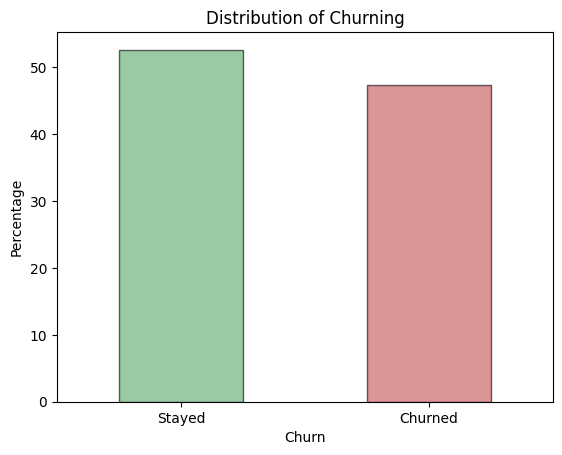

In [7]:
(df['Churn'].value_counts(normalize=True)*100).plot(
    kind='bar',
    color=['#55A868', '#C44E52'],
    alpha=0.6,edgecolor='k'
)
plt.title('Distribution of Churning')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['Stayed', 'Churned'], rotation=0)
plt.show()


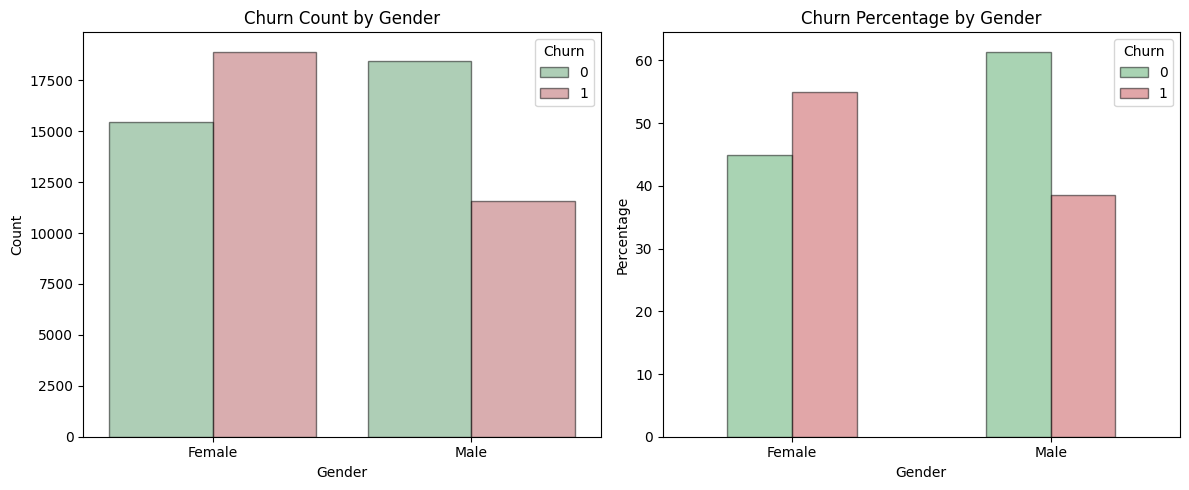

In [8]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df,x='Gender',hue='Churn',ax=axes[0],palette=['#55A868','#C44E52'],alpha=0.5,edgecolor='k')
axes[0].set_title('Churn Count by Gender')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Gender')
gender_loan=pd.crosstab(df['Gender'],df['Churn'],normalize='index')*100
gender_loan.plot(kind='bar',ax=axes[1],color=['#55A868','#C44E52'],alpha=0.5,edgecolor='k')
axes[1].set_title('Churn Percentage by Gender')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Gender')
axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=0)
plt.tight_layout()
plt.show()

~55% of females churned vs ~38% of males churned. So females churn at a noticeably higher rate.

/tmp/ipykernel_55/651975535.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)


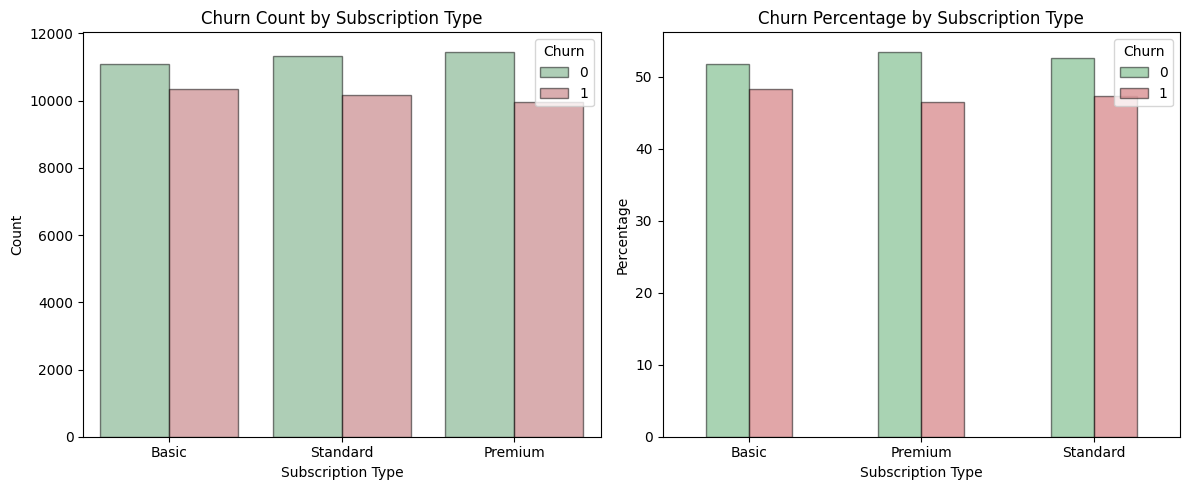

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(
    data=df,
    x='Subscription Type',
    hue='Churn',
    ax=axes[0],
    palette=['#55A868', '#C44E52'],
    alpha=0.5,
    edgecolor='k'
)
axes[0].set_title('Churn Count by Subscription Type')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Subscription Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Percentage plot
subscription_churn = pd.crosstab(
    df['Subscription Type'],
    df['Churn'],
    normalize='index'
) * 100

subscription_churn.plot(
    kind='bar',
    ax=axes[1],
    color=['#55A868', '#C44E52'],
    alpha=0.5,
    edgecolor='k'
)
axes[1].set_title('Churn Percentage by Subscription Type')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Subscription Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

Subscription Type is not a useful predictor here.

/tmp/ipykernel_55/3680377937.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)


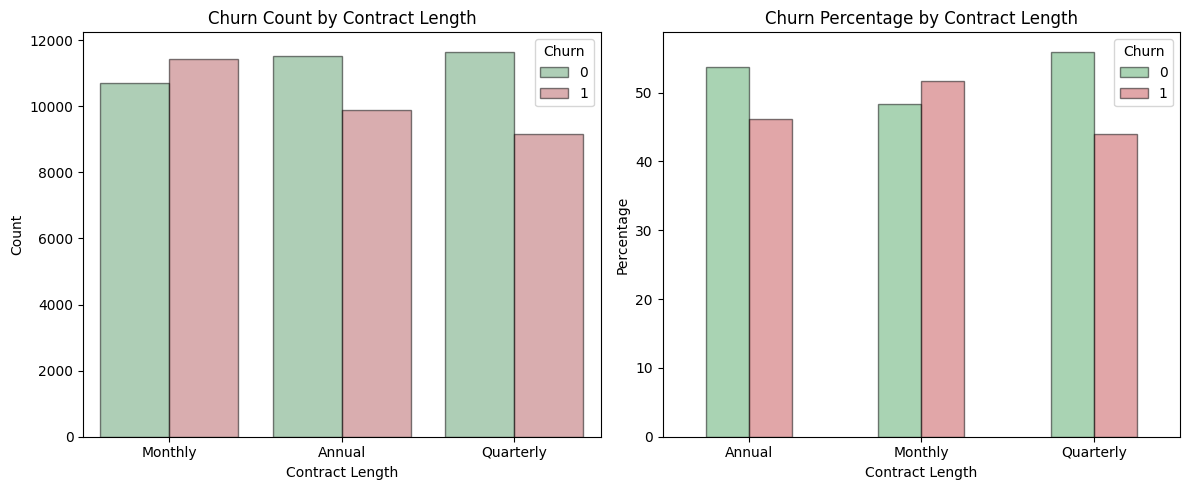

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(
    data=df,
    x='Contract Length',
    hue='Churn',
    ax=axes[0],
    palette=['#55A868', '#C44E52'],
    alpha=0.5,
    edgecolor='k'
)
axes[0].set_title('Churn Count by Contract Length')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Contract Length')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Percentage plot
contract_churn = pd.crosstab(
    df['Contract Length'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.plot(
    kind='bar',
    ax=axes[1],
    color=['#55A868', '#C44E52'],
    alpha=0.5,
    edgecolor='k'
)
axes[1].set_title('Churn Percentage by Contract Length')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Contract Length')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

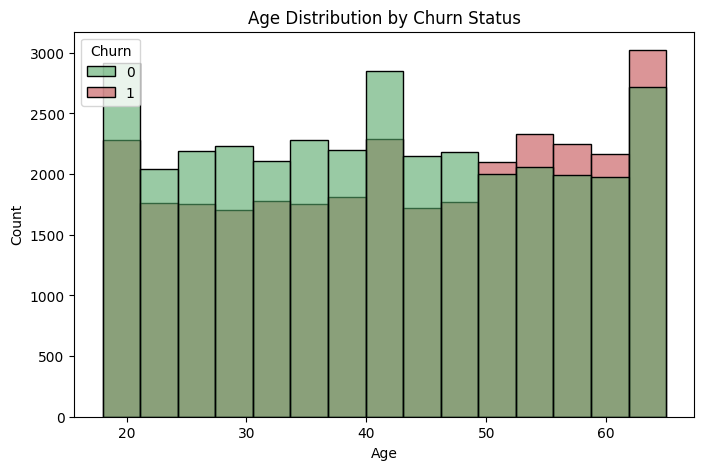

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='Age',
    hue='Churn',          # separates Churn vs Stayed
    bins=15,              # adjust for granularity
    palette=['#55A868','#C44E52'],
    alpha=0.6,            # transparency for overlap
    edgecolor='k'
)
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

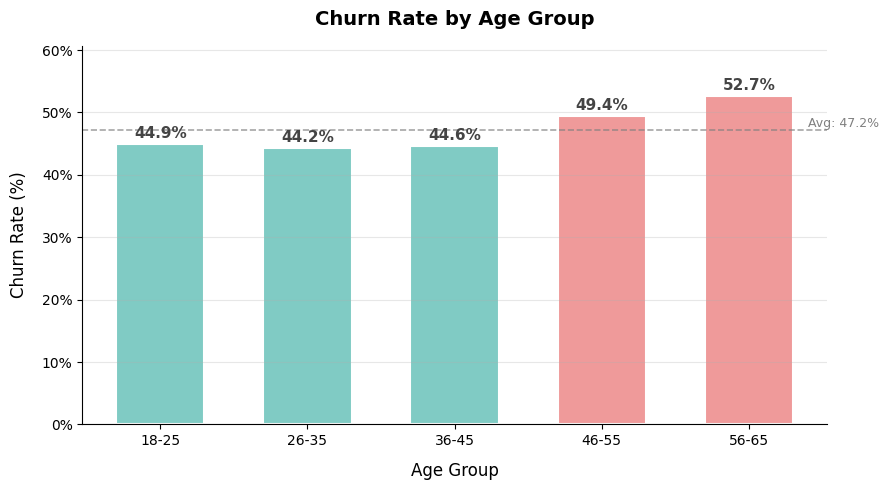

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

age_bins = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
churn_rate = df.groupby(age_bins, observed=True)['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(churn_rate.index, churn_rate.values,
              color=['#80CBC4', '#80CBC4', '#80CBC4', '#EF9A9A', '#EF9A9A'],
              edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#444')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(churn_rate.values) + 8)
ax.set_xlabel('Age Group', fontsize=12, labelpad=10)
ax.set_ylabel('Churn Rate (%)', fontsize=12, labelpad=10)
ax.set_title('Churn Rate by Age Group', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(y=churn_rate.mean(), color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(4.4, churn_rate.mean() + 0.5, f'Avg: {churn_rate.mean():.1f}%', fontsize=9, color='gray')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Older are more likely to churn than younger , but diff is only 8% , not dramtic but still important

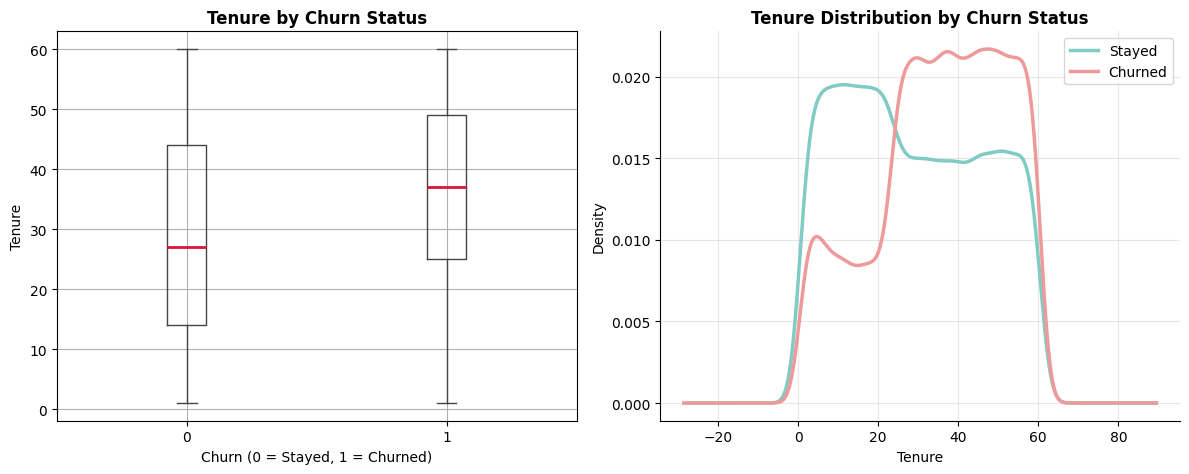

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
df.boxplot(column='Tenure', by='Churn', ax=axes[0],
           boxprops=dict(color='#444'),
           medianprops=dict(color='crimson', linewidth=2),
           whiskerprops=dict(color='#444'),
           capprops=dict(color='#444'))
axes[0].set_title('Tenure by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn (0 = Stayed, 1 = Churned)')
axes[0].set_ylabel('Tenure')
plt.suptitle('')

# KDE
for churn_val, color, label in zip([0, 1], ['#80CBC4', '#EF9A9A'], ['Stayed', 'Churned']):
    df[df['Churn'] == churn_val]['Tenure'].plot.kde(ax=axes[1], color=color, linewidth=2.5, label=label)

axes[1].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Tenure')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

 Lower tenure customers are mostly staying, and higher tenure customers are churning more. Our original hypothesis ("longer tenure lessens churn") is wrong for this dataset.

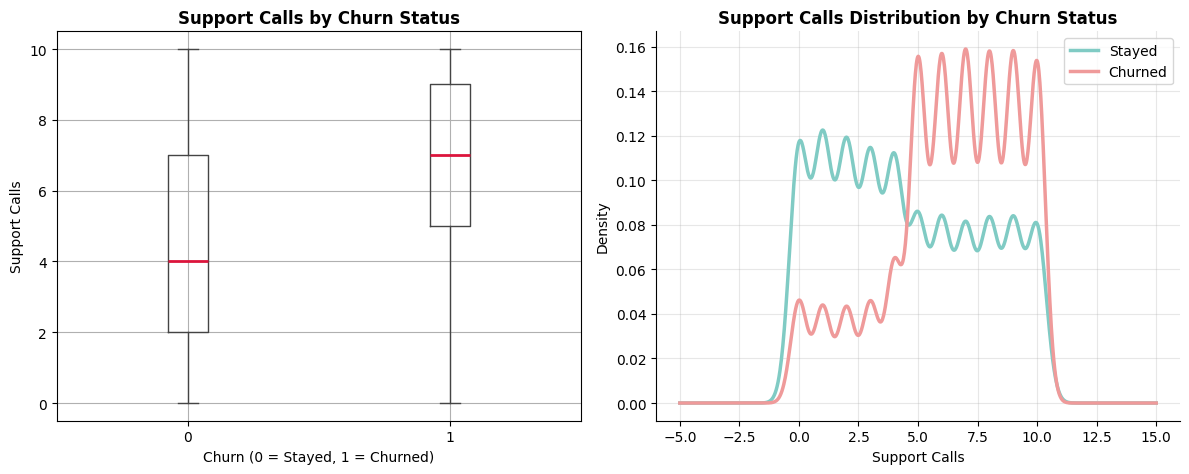

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
df.boxplot(column='Support Calls', by='Churn', ax=axes[0],
           boxprops=dict(color='#444'),
           medianprops=dict(color='crimson', linewidth=2),
           whiskerprops=dict(color='#444'),
           capprops=dict(color='#444'))
axes[0].set_title('Support Calls by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn (0 = Stayed, 1 = Churned)')
axes[0].set_ylabel('Support Calls')
plt.suptitle('')

# KDE
for churn_val, color, label in zip([0, 1], ['#80CBC4', '#EF9A9A'], ['Stayed', 'Churned']):
    df[df['Churn'] == churn_val]['Support Calls'].plot.kde(ax=axes[1], color=color, linewidth=2.5, label=label)

axes[1].set_title('Support Calls Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Support Calls')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

more support calls = more likely to churn.

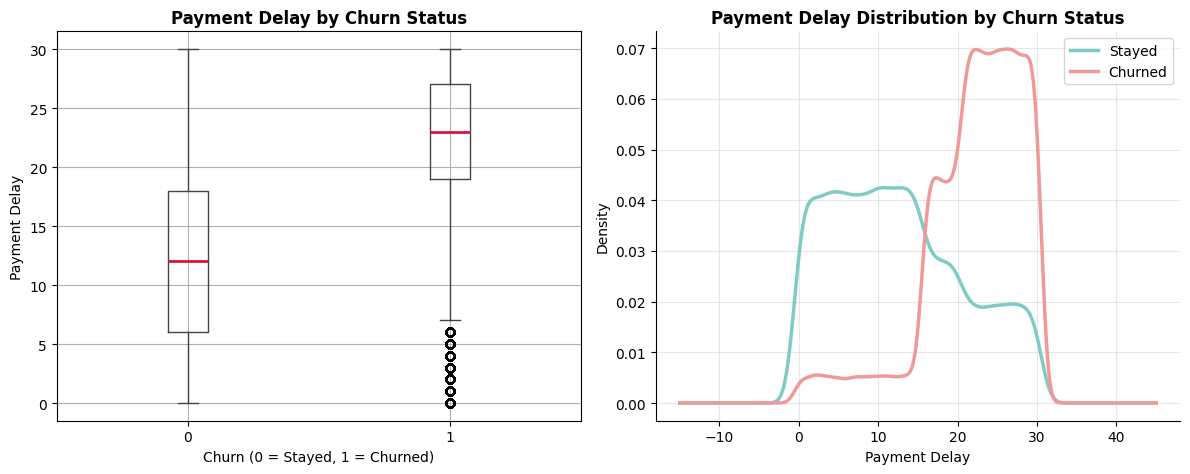

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
df.boxplot(column='Payment Delay', by='Churn', ax=axes[0],
           boxprops=dict(color='#444'),
           medianprops=dict(color='crimson', linewidth=2),
           whiskerprops=dict(color='#444'),
           capprops=dict(color='#444'))
axes[0].set_title('Payment Delay by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn (0 = Stayed, 1 = Churned)')
axes[0].set_ylabel('Payment Delay')
plt.suptitle('')

# KDE
for churn_val, color, label in zip([0, 1], ['#80CBC4', '#EF9A9A'], ['Stayed', 'Churned']):
    df[df['Churn'] == churn_val]['Payment Delay'].plot.kde(ax=axes[1], color=color, linewidth=2.5, label=label)

axes[1].set_title('Payment Delay Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Payment Delay')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The separation between the two groups is very clean — churned customers have significantly higher payment delays, and the KDE shows almost no overlap in the extremes.
Also notice those outlier dots on the churned boxplot at the low end (0-6) — a small group of churned customers had almost no payment delay, which is interesting but they're a minority.

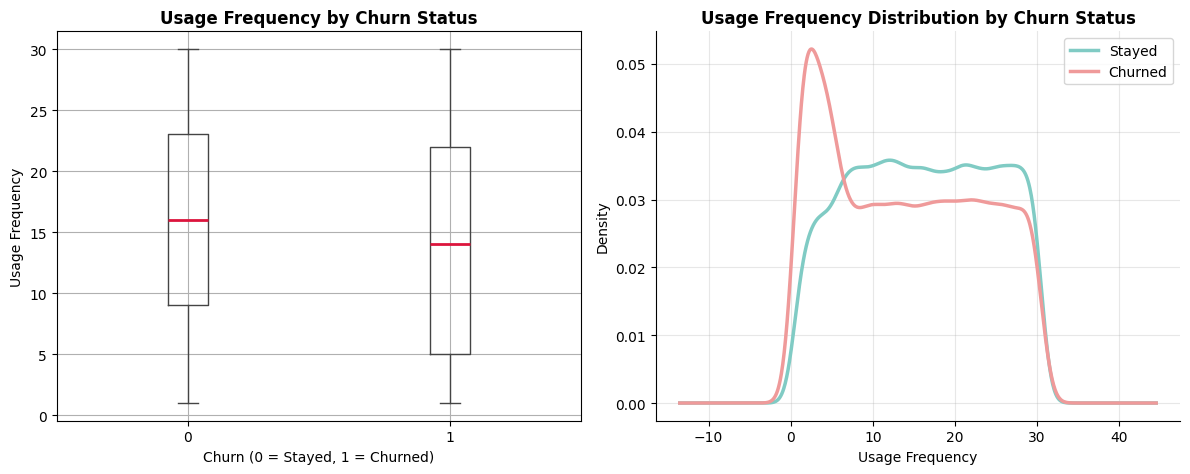

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
df.boxplot(column='Usage Frequency', by='Churn', ax=axes[0],
           boxprops=dict(color='#444'),
           medianprops=dict(color='crimson', linewidth=2),
           whiskerprops=dict(color='#444'),
           capprops=dict(color='#444'))
axes[0].set_title('Usage Frequency by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn (0 = Stayed, 1 = Churned)')
axes[0].set_ylabel('Usage Frequency')
plt.suptitle('')

# KDE
for churn_val, color, label in zip([0, 1], ['#80CBC4', '#EF9A9A'], ['Stayed', 'Churned']):
    df[df['Churn'] == churn_val]['Usage Frequency'].plot.kde(ax=axes[1], color=color, linewidth=2.5, label=label)

axes[1].set_title('Usage Frequency Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Usage Frequency')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Distribution is almost same but kde showed that big spike at very low usage (1-5), then flat across the rest , which tells 

Low engagement customers are leaving

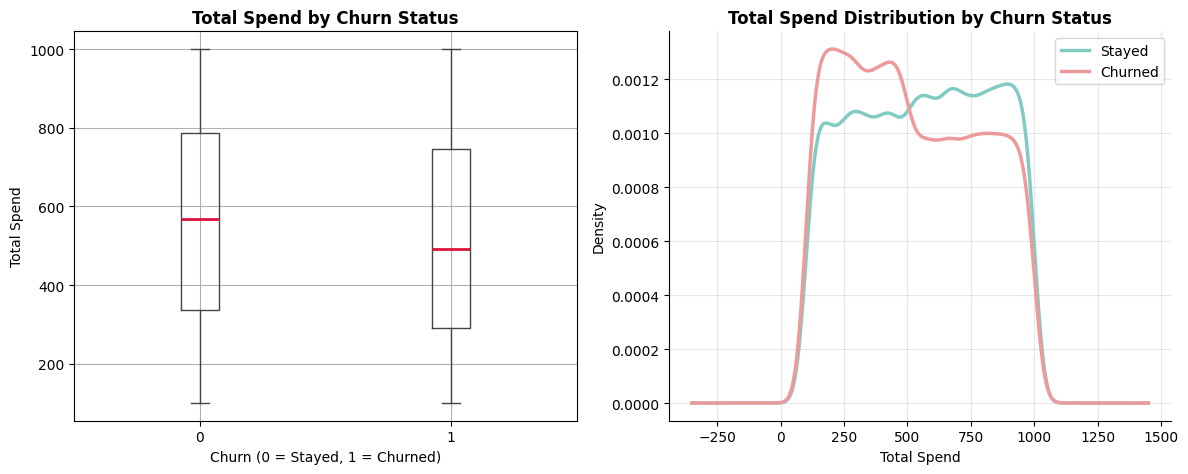

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
df.boxplot(column='Total Spend', by='Churn', ax=axes[0],
           boxprops=dict(color='#444'),
           medianprops=dict(color='crimson', linewidth=2),
           whiskerprops=dict(color='#444'),
           capprops=dict(color='#444'))
axes[0].set_title('Total Spend by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn (0 = Stayed, 1 = Churned)')
axes[0].set_ylabel('Total Spend')
plt.suptitle('')

# KDE
for churn_val, color, label in zip([0, 1], ['#80CBC4', '#EF9A9A'], ['Stayed', 'Churned']):
    df[df['Churn'] == churn_val]['Total Spend'].plot.kde(ax=axes[1], color=color, linewidth=2.5, label=label)

axes[1].set_title('Total Spend Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Total Spend')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

So lower spenders churn more, higher spenders tend to stay

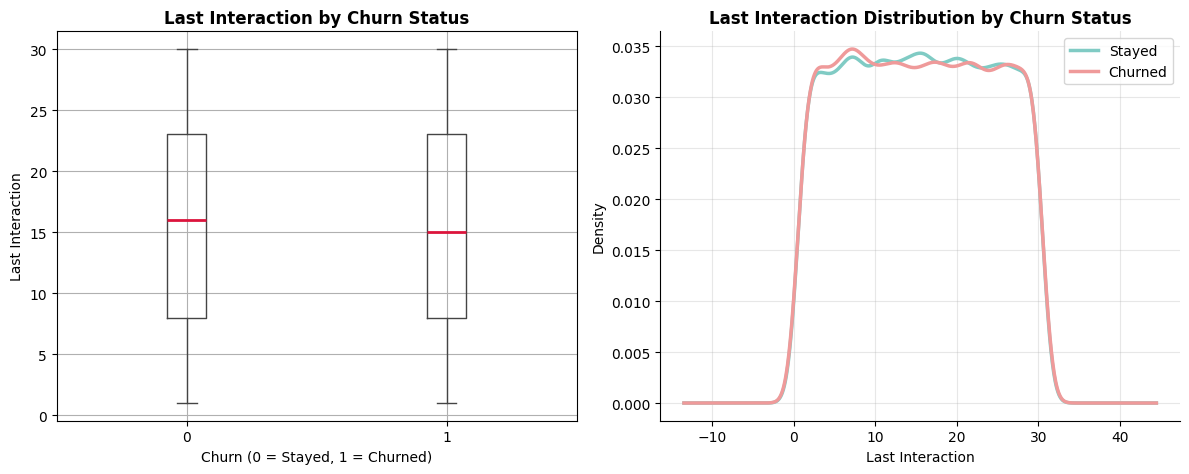

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
df.boxplot(column='Last Interaction', by='Churn', ax=axes[0],
           boxprops=dict(color='#444'),
           medianprops=dict(color='crimson', linewidth=2),
           whiskerprops=dict(color='#444'),
           capprops=dict(color='#444'))
axes[0].set_title('Last Interaction by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn (0 = Stayed, 1 = Churned)')
axes[0].set_ylabel('Last Interaction')
plt.suptitle('')

# KDE
for churn_val, color, label in zip([0, 1], ['#80CBC4', '#EF9A9A'], ['Stayed', 'Churned']):
    df[df['Churn'] == churn_val]['Last Interaction'].plot.kde(ax=axes[1], color=color, linewidth=2.5, label=label)

axes[1].set_title('Last Interaction Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Last Interaction')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

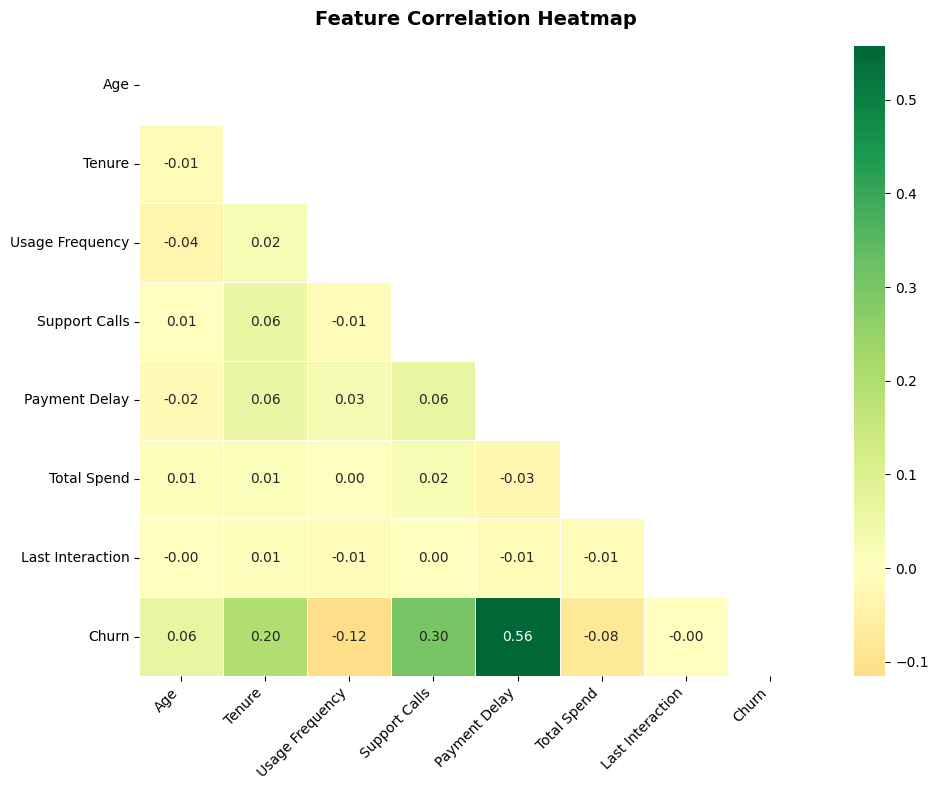

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
# Selects only numeric columns for correlation calculation
corr = df.select_dtypes(include=[np.number]).drop(columns=['CustomerID'], errors='ignore').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, linecolor='white', annot_kws={'size': 10}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

ROC-AUC: 0.9020


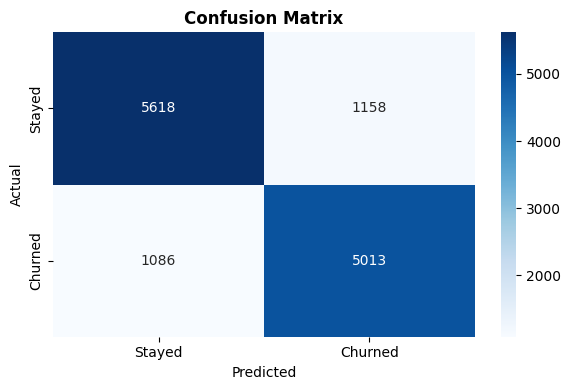

In [22]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Step 1: Drop CustomerID
df_model = df.drop(columns=['CustomerID'])

# Step 2: Encode categoricals
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])
df_model['Subscription Type'] = le.fit_transform(df_model['Subscription Type'])
df_model['Contract Length'] = le.fit_transform(df_model['Contract Length'])

# Step 3: Split features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Step 4: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 5: Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Train Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Step 7: Evaluate
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', ax=ax,
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

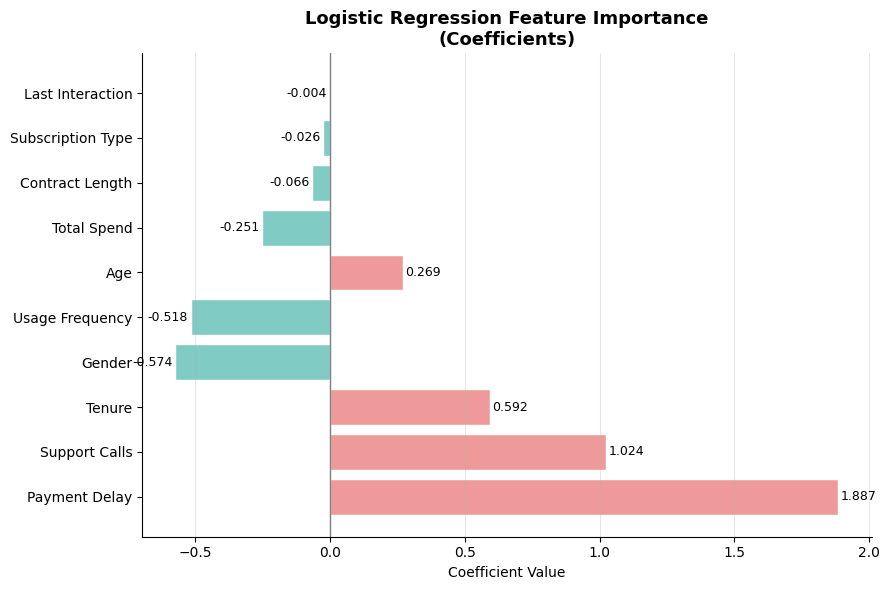

          Feature  Coefficient
    Payment Delay     1.886524
    Support Calls     1.024444
           Tenure     0.591899
           Gender    -0.573679
  Usage Frequency    -0.517796
              Age     0.269117
      Total Spend    -0.251497
  Contract Length    -0.065834
Subscription Type    -0.025789
 Last Interaction    -0.004000


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get coefficients
feature_names = X.columns.tolist()
coefficients = lr.coef_[0]

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#EF9A9A' if c > 0 else '#80CBC4' for c in feat_imp['Coefficient']]
bars = ax.barh(feat_imp['Feature'], feat_imp['Coefficient'], color=colors, edgecolor='white')

ax.axvline(x=0, color='gray', linewidth=1)
ax.set_title('Logistic Regression Feature Importance\n(Coefficients)', fontweight='bold', fontsize=13)
ax.set_xlabel('Coefficient Value')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, feat_imp['Coefficient']):
    ax.text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))